# 1D Invicid Burgers Equation Simulation

## Import Library

In [119]:
import numpy as np
import matplotlib.pyplot as plt

## Setup the Domain

In [120]:
L = 4   # Length of the domain
N = 400 # Number of grid points (increased for better resolution)

dx = L / N  # Grid spacing
print("Grid spacing (dx):", dx)

# endpoint=False: x[0]=0, x[-1]=L-dx (no duplicate at x=L for periodic BC)
x = np.linspace(0, L, N, endpoint=False)

cfl   = 0.8
u_max = 1.0

dt = cfl * dx / u_max
print("Time step size (dt):", dt)

nt = 200
T  = nt * dt
print("Total simulation time (T):", T)


Grid spacing (dx): 0.01
Time step size (dt): 0.008
Total simulation time (T): 1.6


### INITIAL CONDITION: A Gaussian pulse

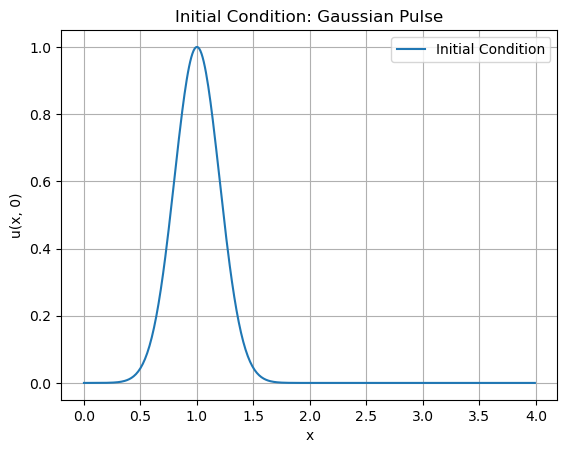

In [121]:
x0    = 1.0  # Initial position of the pulse
sigma = 0.2  # Width of the pulse (was 0.05 — too narrow, only 2.5 cells per sigma)

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
plt.plot(x, u0, label='Initial Condition')
plt.title('Initial Condition: Gaussian Pulse')
plt.xlabel('x')
plt.ylabel('u(x, 0)')
plt.legend()
plt.grid()
plt.show()


## Solve Invicid Burgers Equation

In [122]:
def upwind_invicid_burgers(u, dx, dt):
    u_left  = np.roll(u,  1)   # u_{i-1} for all i, wraps u[0] → u[-1] (periodic BC)
    u_right = np.roll(u, -1)   # u_{i+1} for all i, wraps u[-1] → u[0]  (periodic BC)

    # General upwind: use backward space when u > 0, forward space when u < 0
    conv = np.maximum(u, 0) * (u - u_left) + np.minimum(u, 0) * (u_right - u)

    return u - dt / dx * conv

u = np.copy(u0)
u_history = [u.copy()]

for n in range(nt):
    u = upwind_invicid_burgers(u, dx, dt)
    u_history.append(u.copy())

## Time of Shock

Theoretical shock formation time: t_s = 0.3300
Corresponding step index: 41


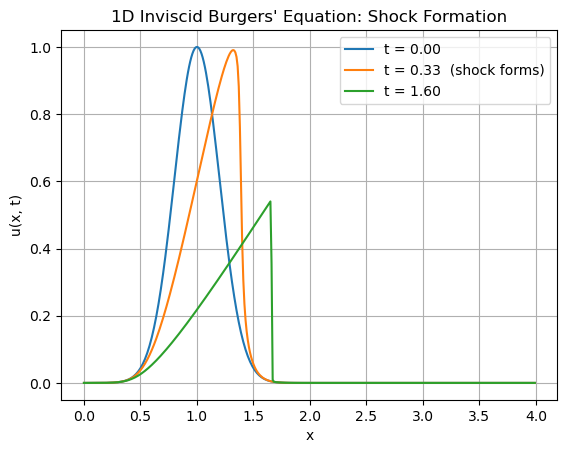

In [123]:
import numpy as np

# Compute shock time from the initial condition — don't hardcode it!
# t_s = -1 / min(du0/dx)
du0dx   = np.gradient(u0, dx)
t_shock = -1.0 / np.min(du0dx)
print(f"Theoretical shock formation time: t_s = {t_shock:.4f}")
print(f"Corresponding step index: {int(t_shock / dt)}")

plt.plot(x, u_history[0],               label='t = 0.00')
plt.plot(x, u_history[int(t_shock/dt)], label=f't = {t_shock:.2f}  (shock forms)')
plt.plot(x, u_history[-1],              label=f't = {T:.2f}')
plt.title("1D Inviscid Burgers' Equation: Shock Formation")
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()


## Result

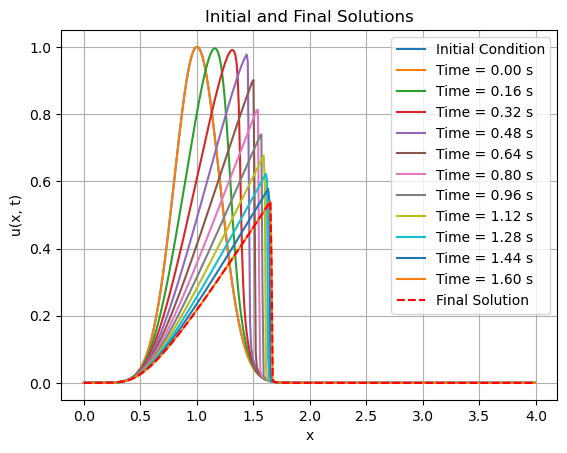

In [124]:

u0 = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2)) # Initial condition
plt.plot(x, u0, label='Initial Condition')
for n in range(0, nt + 1, 20):
    plt.plot(x, u_history[n], label=f'Time = {n*dt:.2f} s')
plt.plot(x, u, label='Final Solution', linestyle='--', color='red')
plt.title('Initial and Final Solutions')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()
plt.grid()
plt.show()
